# Applications: DNA sequences
<br>

This notebook demonstrates applications of Chaos Game Representation (CGR)
and Frequency Chaos Game Representation (FCGR) for DNA sequences.

Examples include:
- visualization of viral DNA sequences (HIV),
- visualization of genomic sequences,
- contrast enhancement using quantile normalization,
- influence of nucleotide vertex assignment.

In [1]:
from kaospy import CGR
from kaospy import FCGR
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm

<br>

## HIV

The first example uses an HIV DNA sequence
(B.MM.1999.mSTD101.AB097870).


In [2]:

hiv ="AAATCTCTAGCAGTGGCGCCCGAACAGGGACGCGAAAGCGAAAGTAAGACCAGAGAAGATCTCTCGACGCAGGACTCGGCTTGCTGAAAGCGCGCGCAGCAAGAGGCGAGAGCGGCGGCTGGTGAGTACGCCAAAAATCTTGACTAGCGGAGGCTAGAAGGAGAGAGATGGGTGCGAGAGCGTCAGTATTAAGCGGGGGACAATTAGATAGATGGGAAAAAATTCGGCTAAGGCCAGGAGGAAAGAAAAAATATAGATTAAAGCATATAGTATGGGCAAGCAGGGAACTGGAACGATTCGCAGTTAATCCTGGCCTGCTAGAAACAGCAGGAGGCTGTAGACAAATACTAGAACAGCTACAACCATCACTTAAGACAGGATCAGAAGAACTTAGATCATTATTCAATACAGTAGCAACCCTCTATTGTGTGCATCAAAGGATAGAGATAAAAGACACCAAGGAAGCTTTAGAAAAGATAGAGGAAGAGCAAAACAAAAGTAAGAAAAAGACACAGCAAACAGCAGCTGACACAGGAAAACACAGCCAGGTCAACCAGGTCAGGCAAAATTACCCTATAGTGCAAAACCTTCAGGGGCAAATGGTACATCAGCCCATATCACCTAGAACTTTAAATGCATGGGTAAAAGTAATAGAAGAGAAGGCTTTTAGTCCAGAAGTGATACCCATGTTTTCAGCATTATCAGAAGGAGCCACCCCACAAGATTTAAACACCATGTTAAACACAGTGGGGGGACATCAAGCAGCCATGCAAATGTTAAAAGAAACCATCAATGAGGAAGCTGCAGAATGGGATAGATTGCATCCAGTGCATGCAGGGCCAGCTGCACCAGGCCAGATGAGAGAACCAAGGGGAAGTGACATAGCAGGAACTACTAGTACCCTTCAGGAGCAAATAGGATGGATGACAAGTAATCCAGCTATCCCAGTAGGAGAAATCTATAAAAGATGGATAATCCTGGGATTAAATAAAATAGTAAGAATGTATAGCCCTGTCAGCATTCTGGACATAAAACAAGGACCAAAGGAACCCTTTAGAGATTATGTAGATCGGTTCTATAAAACTCTAAGGGCCGAGCAATGCACACAAGAAGTAAAACATTGGATGACAGAAACCTTGTTGGTCCAAAATGCAAACCCAGATTGTAAGACTATTTTAAAAGCGTTAGGACCAGCAGCCACACTAGAAGAAATGATGACAGCATGTCAGGGAGTAGGGGGACCCGGCCATAAAGCAAGAGTCTTGGCTGAAGCAATGAGCCAAGTAACAAATCCAGCTAATATAATGATGCAGAGAGGCAATTTTAGGAATCAAAGAAAGACTGTCAAGTGTTTCAATTGTGGCAAAGAAGGGCATATAGCCAAAAATTGCAGGGCCCCTAGGAAAAAGGGCTGTTGGAAATGTGGAAAGGAAGGACACCAAATGAAAGACTGTACTGAGAGACAGGCTAATTTTTTAGGGAAAATCTGGCCTTCCCACAAGGGAAGGCCAGGGAATTTTCTTCAGAGCAGACCAGAGCCAACAGCCCCACCAGAGGAGAGCTTCAGGTTTGGGGAGGAGACAACAACTCCAGCTCAGAAGCAGGAGCCGATAGACAAGGAACTGTATCCTTTAGCTTCCCTCAAATCACTCTTTGGCAACGACCCCTCGTCACAATAAAGATAGGGGGGCAATTAAAGGAAGCTCTATTAGATACAGGAGCAGATGATACAGTATTAGAAGACATGGATTTGCCAGGAAGATGGAAACCAAAAATGATAGGGGGAATTGGAGGTTTTATCAAAGTAAGACAGTATGATCAGATACCCATAGAAATCTGTGGACACAAAGCTATAGGTACAGTATTAGTAGGACCAACACCTGTCAACATACTAATTGGAAGAAATCTGCTGACTCAGGTTGGTTGCACTTTAAATTTTCCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAATGGATGGCCCAAAAGTTAAACAATGGCCATTGACAGAAGAAAAAATAAAAGCATTAGTAGAAATTTGTACAGAAATGGAAAAGGAAGGGAAAATTTCAAAAATTGGGCCTGAAAATCCATACAATACTCCAGTATTTGCCATAAAGAAAAAAAATAGTACTAGATGGAGAAAATTAGTAGATTTTAGGGAACTTAATAGAAGAACTCAAGACTTCTGGGAAGTTCAATTAGGAATACCACATCCTGCAGGGTTAAAAAAGAAAAAATCAGTAACAGTCCTGGATGTGGGTGATGCATACTTCTCAGTTCCTTTAGATAAAGACTTCAGGAAGTATACTGCATTTACCATACCTAGTGTAAACAATGAGACACCAGGGGTTAGATATCAGTACAATGTGCTTCCACAGGGATGGAAAGGATCACCAGCAATATTCCAATGTAGCATGACAAAAATCTTAGAGCCTTTTAGAAAGCAAAATCCAGATATAGTTATCTATCAATACATGGATGATTTGTATGTAGGATCTGACTTAGAAATAGGGCAGCATAGAACAAAAATAGATGAGTTAAGACAACATCTGTTGAAGTGGGGATTTTACACACCAGACAAAAAACATCAGAAAGAACCCCCATTCCTTTGGATGGGTTATGAACTACATCCAGATAAATGGACAGTACAGCCTATAGTGCTGCCAGAAAAAGACAGCTGGACTGTCAATGACATACAGAAGTTAGTGGGAAAGTTGAATTGGGCAAGTCAGATTTATGCAGGGATTAAGGTAAAGGAATTATGTAAACTCCTTAGGGGAACCAAAGCATTAACAGAAGTAGTACCACTAACAGAAGAAGCAGAGCTAGAACTGGCAGAAAACAGGGAAATTCTAAAAGAACCAGTACATGGAGTGTATTATGACCCATCAAAAGAATTAGTAGCAGAAATACAGAAGCAGGGGCTAGGCCAATGGACATACCAAATTTATCAGGAACCATATAAAAATCTGAAAACAGGAAAGTATGCAAAAATGAGGGGTGCCCACACTAATGATGTAAAACAATTAACAGAGGCAGTGCAAAAAATAGCCACAGAAAGCATAGTGATATGGGGGAAGACTCCTAAATTTAAGCTACCCATACAAAAGGAAACATGGGAAACATGGTGGGTAGAGTATTGGCAAGCCACCTGGATTCCTGAATGGGAGTTTGTCAATACCCCTCCCTTAGTGAAACTATGGTATCAGTTAGAGAAAGAACCCATAGAAGGAGTAGAAACTTTCTATGTAGATGGGGCAGCTAATAGGGAGACTAAATTAGGAAGAGCAGGATATGTTACTAACAAAGGAAGACAAAAAGTTATCACTCTAACTGACACAACAAATCAGAAGACTGAGTTACAAGCAATTAATTTAGCTTTGCAGGATTCAGGAGTAGAAGTAAACATAGTAACAGACTCACAATATGCATTAGGAATCATTCAAGCACAACCAGATAAGAGTGAATCAGAGTTAGTCAGCCAAATAATAGAGCAGTTAATAAAAAAGGAAAAAGTCTACCTGGCATGGGTGCCAGCACACAAAGGAATTGGAGGGAATGAACAAATAGATAAATTAGTCAGTGCTGGAATCAGGAGAGTACTATTTTTAGATGGAATAGAAAAGGCCCAAGAAGATCATGAGAAATATCACTGTAATTGGAGAGCAATGGCTAGTGATTTTAACCTACCACCTATAGTAGCAAAAGAAATAGTAGCCAGCTGTGATAAATGTCAGTTAAAAGGAGAAGCCATGCATGGACAAGTAGACTGTAGCCCAGGAATATGGCAACTAGACTGTACACATTTAGAAGGAAAAATTATCCTGGTAGCAGTTCATGTAGCCAGTGGATATATAGAAGCAGAAGTTATTCCAACAGAGACAGGGCAGGAAACAGCATACTTTATCCTAAAGTTAGCAGGAAGATGGCCAGTAAAAACAATACATACAGACAATGGCAGAAATTTCACCAGTAATTCAGTTAAGGCTGCCTGTTGGTGGGCAGGGATCAAGCAGGAATTTGGCATTCCCTACAATCCCCAAAGTCAAGGAGTAGTAGAATCTATGAATAAAGAATTAAAGAAAATTGTAGAACAGGTAAGAGATCAAGCTGAACATCTTGAGACAGCAGTACAAATGGCAGTATTCATCCACAATTTTAAAAGAGAAGGGGGGATTGGAGGGTACAGTGCAGGGGAAAGAATAGTAGACATAATAGCAACAGACATACAAACTAGAGAACTACAAAAACAAATTACAAAAATTCAAAATTTTCGGGTTTATTACAGGGACAACAGAGATCCACTTTGGAAAGGACCAGCAAAGCTCCTTTGGAAAGGTGAAGGGGCAGTAGTAATACAAGATAATAGTGACATAAAAGTAGTGCCAAGAAGAAAAGCAAAGATCATTAGGGACTATGGAAAACAGATGGCAGGTGATGATTGTGTGGCAAGTAGACAGGATGAGGATTAGAACATGGAAAAGTCTAGTAAAACACCATATGTATATTTCAAAGAAAGCTAAGGGATGGTCATATAAACATCACTATGATAGCACTCACCCAAAAATAAGTTCAGAAGTACACATCCCACTAGGGGATGCTAGATTGGTAATAACAACATATTGGGGTCTGCATACAGGAGAAAGAGACTGGCATTTGGGCCAGGGAGTCTCCATAGAATGGAGGGAAAAGAGATATAGCACACAAGTAGACCCTGGCCTAGCAGACCAACTGATTCACCTGTATTATTTTGATTGTTTTCAGAATCTTGCTATAAGAGATGCCATTTTAGGACGTATAGTTAGCCCTAGTTGTGATTATCAAGCAGGACATAACAAAGTAGGATCTCTACAGTACTTGGCACTAGCAGCATTAATAACACCTAAAAAAGAGAAGCCACCTTTGCCTAGTGTTAGGAAATTGACAGAGGATAGATGGAACAAGCCCCAGAGGACCAAGGGCCACAGAGAGAGCCATACAATGAATGGACACTAGAGCTTTTAGAGGAGCTTAAGAGAGAAGCTGTTAGACATTTTCCTAGGCCATGGCTCCATGGGTTAGGACAATTTATCTATGAAACATATGGGGATACTTGGGCAGGAGTGGAAGCCATAATAAGAATTCTGCAACAATTGCTGTTTATTCATTTCAGAATTGGGTGTCAACATAGCAGAATAGGCATTACTCGACAGAGGAGAGCAAGAAATGGAGCCAGTAGATCCTAGATTAGAGCCTTGGAAGCATCCAGGAAGTCAGCCTAAGACTGCTTGTACCAATTGCTATTGTAAAAAGTGCAATTGCTATTGTAAAAGTGCTGCTTCATGCAGTTGTTTCATAAAAAAAGGCTTAGGCATCTTCTATGGCAGGAAGAAGCGAAGACAAGACGAACAGCCTCCTCAAGACAGCCAGACTCATCAAGCTTCTTTATCAAAGCAGTAAGTAGTATATGTAATGCAAGCTTTAATCATTTGGGCAATAGTAGCCTTAGTAGTAGCAGCAATAATAGCAATAGTTGTGTGGACCATAGCATTCATAGAATATAGGAAATTATTAAAACTAGTAAAAGAAATAGAAAGGTTAATTGATAGAATAAGAGAAAGAGCAGAAGACAGTGGCAATGAGAGTGACGGGGATCAGGAAGAATTATCAGCATTTATGGAAATGGGGCACGATGCTCCTTGGAATGTTGATGATCTGTAGTGCTACAACTAAAGAAAAATCGTGGGTCACAGTCTATTATGGGGTACCTGTATGGAAAGAAGCAATCACCACTCTATTTTGTGCATCAGATGCTAAAGCATATGATACAGAGATACATAATGTTTGGGCCACACATGCCTGTGTACCCACAGACCCCAACCCACAGGAAGTAGTCTTGGGAAATGTGACAGAAAACTTTAACATGTGGAAAAATAATATGGTAGATCAGATGCATGAAGATATAATCAGTTTATGGGATCAAAGTCTAAAACCATGTGTAAAACTAACCCCACTCTGTGTCACTTTAAATTGCATTGATTATGTGAAAAATGCTACTAATACTAATAGTACTGCTACTAATACCACTAGTACAACCAATAGTACAATAGAGGGAGGAGAAATGAAAAACTGCTCTTTCAATATCACCACAAGCATAAAAAAGGTGAAAGACCATGCACTTTTTTATAAACTTGATATAGTAAAAATGAAAGATGATAGTGCCAATAATAACAGCTATAGGTTGATAAATTGTAACTCCTCAGTCATTACACAAGCTTGTCCAAAGGTATCCTTTGAGCCAATTCCCATACATTATTGTGCCCCGGCTGGTTTTGCGATTCTAAAGTGTAACAATAAAACATTCAATGGAACAGGACCATGTACAAATGTCAGTACAGTACAATGTACACATGGAATTAGGCCAGTAGTATCAACTCAACTGCTGTTAAATGGCAGTCTAACAGAAGAAGGGATAGTAATTAGATCTAGCAATTTCACAGACAATGCTAAAGTCATTATAGTACAGCTGAATGAATCTGTACGAATTGATTGTATAAGACCTAACAACAATACAAGAAAAAGTATAAATCTAGGACCAGGGCAAGCATGGTATACAACAGGAGACATAATAGGAGATATAAGACAAGCACATTGTAACCTTACTAGCAAAAATTGGAATAACACTTTAATACAGGTAACTGAAAAATTAAGAGAACAATTTGGGAACAAAACAATAGACTTTAAACAATCCTCAGGAGGGGACCCAGAGATTGTAATGCACAGTTTTAATTGTGGAGGGGAATTCTTCTACTGTAATACATCACAACTGTTTAATAGTACTTGGTATGGGAATAATACTAGTACTTGGAATAATACTGCAGAAAATATCACGCTCCCCTGCAGAATAAAACAAATTGTAAACATGTGGCAGGAAGTAGGAAGAGCAATGTATGCCCCTCCCATCGCAGGACAAATTAAGTGTTCATCAAATATTACAGGGTTGCTGTTAACAAGAGATGGTGGTAATAAGACCAACCCCACCGAGATCTTCAGACCTGCAGGAGGAGATATGAGGGACAATTGGAGAAGTGAATTATATAAATATAAAGTAGTAAGAATTGAACCATTAGGAGTAGCACCCACCAGGGCAAAGAGAAGAGTGGTGCAAAGAGAAAAAAGAGCAGTGGGAACGCTAGGAGCTATGTTCCTTGGGTTCTTGGGAGCAGCAGGAAGCACTATGGGCGCAGCGTCAATAACGCTGACGGTACAGGCCAGACAATTATTGTCTGGTATAGTGCAACAGCAAAGAAATTTGCTGAGAGCTATTGAGGCGCAACAGCATTTGTTGCAACTCACAGTCTGGGGCATCAAACAGCTCCAGGCAAGAGTCCTGGCTGTGGAAAGATACCTGAAGGATCAACAGCTCATGGGGATTTGGGGTTGCTCTGGAAAACTCATTTGCACCACTGCTGTGCCTTGGAATACCAGTTGGAGTAATAAATCTCTGGATGACATTTGGAATAACATGACTTGGATGGAGTGGGAAAGAGAAATTCACAATTACACAGCAGAAATATACACCTTAATTGAACAATCGCAGAACCAGCAAGAAAAGAATGAACTAGAATTATTAAAATTGGATACGTGGGCAAGTTTGTGGAGTTGGTTTGACATATCAAATTGGCTGTGGTATATAAGAATATTCATAATGATAGTAGGAGGCTTAATAGGTTTAAGAATAGTTTTTGCTGTACTTTCTATAGTAAATAGAGTTAGCCAGGGGTACTCACCATTGTCGGTTACAGACCCGCTTTCCCAGGCCCAGAGGGGACCCGGCAGGCCCGAAGGAATCGAAGGAGAAGGTGGAGAGCAAGACAGAGGCAGATCAGACAGATTTGTGAACGGATTCTTGACGCTTATCTGGGAGGATCTTCGGAGCCTGTGCCTCTTCAGCTACCACCGCTTGAGAGACTTACTCTGGATTGTGGGACTTCTGGGACGCAGGGGGTGGGAAGCCCTCAGATATTGGTGGAATCTCCTACAGTATTGGATTCAGGAACTAAAGAATAGTGCTGTTAGCTTGCTCAATACCATAGCTATAGCAGTAGCTGAGGGGACAGATAGGATTATAGAAATAGTACAAAGAGCTTATAGAGCCATTCTCCACATACCTACAAGAATAAGACAGGGCTTAGAAAGGGCTTTGCTATAAGATGGGTGGCAAGTGGTCAAAATGCAGTCTGGGTGGATGGCCTAGGGTAAGGGAAAGAATGAGACGCGCTGAGCCAGCAGCAGATGGGGTGGGAGCAGTATCTCGAGACCTGGAAAAACATGGAGCAATCACAAGTAGCAATACATCAGCTACTAATGCTGATTGTGCCTGGCTAGAAGCACAAGAGGAGGAGGAAGTAGGTTTTCCAGTCAGACCACAGGTACCTTTAAGACCAATGACTTACAAGGCAGCCCTCGATCTTAGCCACTTTTTAAAAGAAAAGGGGGGACTGGAAGGGCTAATTCACTCCCAAAAAAGGCAAGATATCCTTGATATGTGGATCTACCATACACAAGGCTACTTCCCTGATTGGCAGAGCTACACCCCAGGACCAGGGGTCAGATTTCCACTGACCTTTGGATGGTGCTTCAAGCTAGTACCAGTTGATCCAGAGCAGGTAGAAGCAGCCACCGCAGGAGAGAACAACAGCTTGTTACATCCTATAAACCAGCATGGAGCAGATGACCCAGAGAAAGAAGTGCTAATGTGGAAGTTTGACAGCCGCTTAGCCTTCCATCACATGGCCCGAGAGAAGCATCCGGAGTACTACAAGAACTGATGACATCGAGCTTTCTACAAGGAACTTTCCGCTGGGGACTTTCCAGGGAGGCGCGGCATGGGCGGGACAGGGGAGTGGCGAGCCCGCAGATGCTGCATATAAGCAGCCGCTTTTGCCTGTACTGGGTCTCTCTAGTCAGACCAGATCTGAGCCCGGGAGCTCTCTGGCTACTAGGGAACCCACTGCTTAAGCCTCAATAAAGCTTGCCTTGAGTGCTTCAAGTAGTGTGTGCCCGTCTGTTGTGTGACTCTGGTAACTAGAGATCCCTCAGACC"


<br>
A standard DNA alphabet (`A`, `G`, `T`, `C`) is used and the CGR
coordinates are calculated using the default nucleotide corner assignment.
<br>

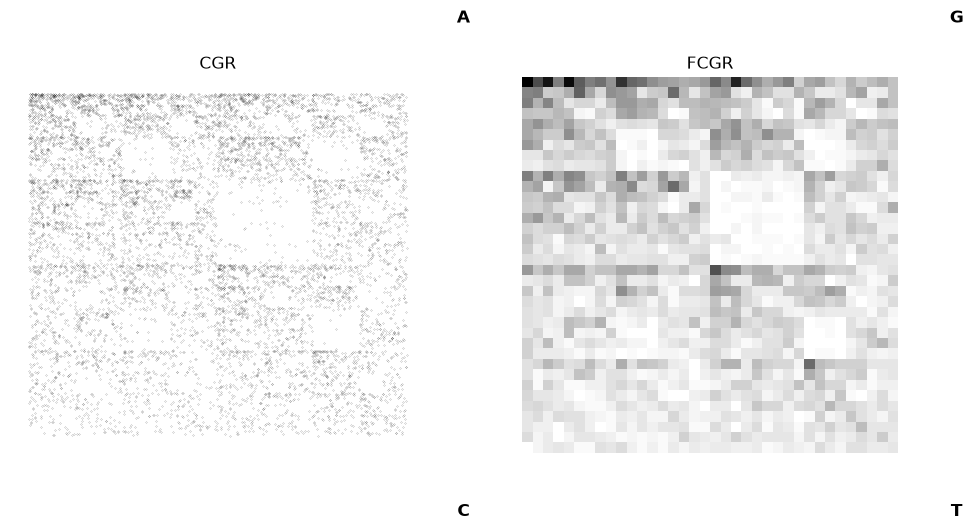

In [4]:
hiv_cgr = CGR(hiv, symbols="DNA") 
# FCGR resolution defines the size of the frequency matrix (36 x 36)
hiv_fcgr=FCGR(hiv_cgr,resolution=36)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

hiv_cgr.plot(ax=axes[0], point_size=0.01)
axes[0].set_title("CGR")

hiv_fcgr.plot(ax=axes[1], labels=True)
axes[1].set_title("FCGR")

plt.tight_layout()
plt.show()

<br>

## Butterfly
<br>

### Loading genomic data

A small FASTA reader is used to load the genome sequence without requiring
additional bioinformatics packages.

In [7]:
def read_fasta(path: str) -> dict[str, str]:

    sequences = {}

    header = None
    sequence = []

    with open(path, "r") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                # save previous sequence
                if header is not None:
                    sequences[header] = "".join(sequence)

                header = line[1:]
                sequence = []

            else:
                sequence.append(line)

        # save last sequence
        if header is not None:
            sequences[header] = "".join(sequence)

    return sequences

<br>
Reading the fasta (First 150 kb of Papilio machaon genome assembly, chromosome: 1):

In [8]:
data=read_fasta("data/butterfly.fasta")

<br>
The example FASTA file contains only one sequence entry.
This sequence is used for the following examples:

In [9]:
butterfly = list(data.values())[0]

<br>

### Plotting the butterfly Example as CGR and FCGR

The butterfly genome segment is represented with a higher FCGR resolution
(300 × 300 bins) to visualize smaller-scale frequency differences.

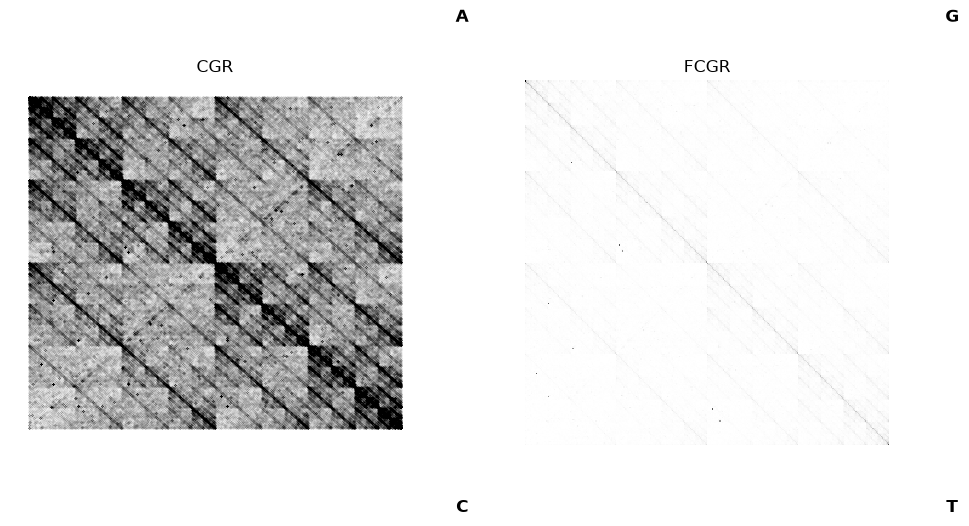

In [10]:
butterfly_cgr = CGR(butterfly, symbols="DNA") 
butterfly_fcgr=FCGR(butterfly_cgr,resolution=300)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

butterfly_cgr.plot(ax=axes[0], point_size=0.0001)
axes[0].set_title("CGR")

butterfly_fcgr.plot(ax=axes[1], labels=True)
axes[1].set_title("FCGR")

plt.tight_layout()
plt.show()

### Quantile-based normalization

FCGR matrices often contain many cells with low frequencies and only a few
cells with very high frequencies. A linear color scale can therefore hide
most of the structure.

To improve the visualization, the values are divided into intervals based
on their quantiles. Each interval contains approximately the same number
of matrix values, which increases the contrast between different regions
of the FCGR.

Here, 8 quantile boundaries are used, resulting in 7 value intervals.
Increasing this number creates finer intensity differences, while smaller
values produce stronger grouping.

In [12]:
# Determine value boundaries based on the distribution of FCGR values.
breaks = np.quantile(
    butterfly_fcgr.matrix,
    np.linspace(0, 1, 8)
)

In [13]:
# Create a normalization that assigns values to discrete intervals.
norm = BoundaryNorm(
    breaks,
    256
)

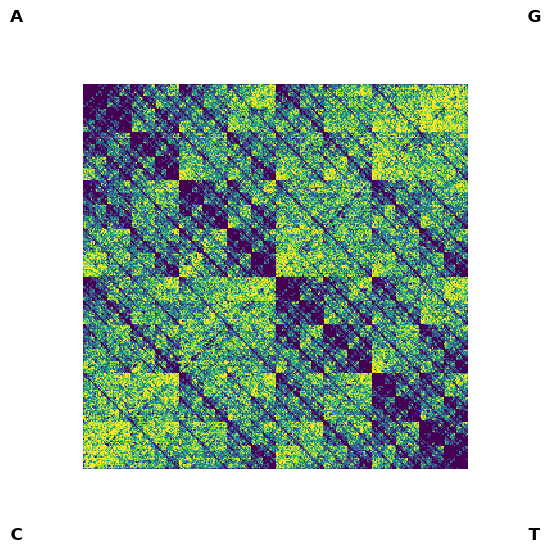

In [14]:
fig, ax = plt.subplots(figsize=(5,5))

butterfly_fcgr.plot(
    ax=ax,
    labels=True,
    cmap="viridis_r",
    norm=norm
)

plt.show()

<br>

## Impact of nucleotide vertex assignment

The assignment of nucleotides to CGR vertices influences the visual
appearance of FCGR patterns.

Different arrangements can represent the same sequence information with
different spatial organization. For example, changing the relative position
of A and T can alter the visual separation of regions with different GC
content.

A different nucleotide ordering is used to demonstrate how the spatial
organization of FCGR patterns depends on the chosen CGR corner assignment.

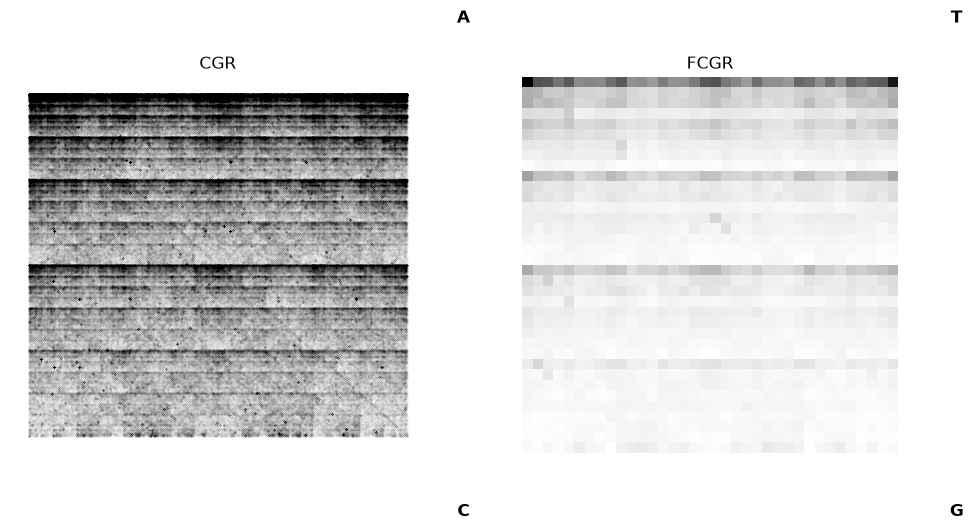

In [15]:
butterfly_cgr = CGR(butterfly, symbols=["A","T","G","C"]) 
butterfly_fcgr=FCGR(butterfly_cgr,resolution=36)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

butterfly_cgr.plot(ax=axes[0], point_size=0.0001)
axes[0].set_title("CGR")

butterfly_fcgr.plot(ax=axes[1], labels=True)
axes[1].set_title("FCGR")

plt.tight_layout()
plt.show()